# Mutual Fund Analytics Capstone Project
## Exploratory Data Analysis (EDA)
This notebook performs an in-depth exploratory data analysis of the synthetic Mutual Fund industry data covering January 2022 through December 2025. It includes trends on NAV, AUM, SIP inflows, investor demographics, folio growth, and portfolio holdings.

## 1. Import Libraries
In this section, we import all necessary Python libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Create reports/charts directory if it doesn't exist
os.makedirs('../reports/charts', exist_ok=True)
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Data
We load all the generated datasets from `data/raw/` into pandas DataFrames.

In [2]:
raw_dir = '../data/raw/'
nav_df = pd.read_csv(raw_dir + 'nav_history.csv', parse_dates=['Date'])
aum_df = pd.read_csv(raw_dir + 'aum_data.csv')
sip_df = pd.read_csv(raw_dir + 'sip_inflows.csv', parse_dates=['Month'])
investor_df = pd.read_csv(raw_dir + 'investor_data.csv')
folio_df = pd.read_csv(raw_dir + 'folio_counts.csv', parse_dates=['Month'])
portfolio_df = pd.read_csv(raw_dir + 'portfolio_holdings.csv')

print('Data loaded successfully.')

Data loaded successfully.


## 3. Data Understanding
Let's check the shape and first few rows of each dataset.

In [3]:
datasets = {'NAV': nav_df, 'AUM': aum_df, 'SIP': sip_df, 'Investor': investor_df, 'Folio': folio_df, 'Portfolio': portfolio_df}
for name, df in datasets.items():
    print(f'{name} Data Shape: {df.shape}')
investor_df.head()

NAV Data Shape: (41720, 3)
AUM Data Shape: (40, 3)
SIP Data Shape: (48, 2)
Investor Data Shape: (10500, 9)
Folio Data Shape: (48, 2)
Portfolio Data Shape: (400, 3)


,Investor_ID,Age,Age_Group,Gender,State,City_Tier,Monthly_SIP,Occupation,Income_Range
0,1,66,60+,Female,West Bengal,Tier 1,572.33,Retired,Below 5L
1,2,35,30-44,Female,Tamil Nadu,Tier 1,5111.74,Salaried,5L-10L
2,3,73,60+,Female,Maharashtra,Tier 2,4968.48,Business,5L-10L
3,4,38,30-44,Female,West Bengal,Tier 3,25019.03,Professional,Above 20L
4,5,20,18-29,Female,Karnataka,Tier 2,5505.75,Professional,5L-10L


## 4. Data Cleaning
We check for missing values or inconsistencies. Since this data is synthetically generated, missing values are minimal. We will still run a check.

In [4]:
missing_values = {name: df.isnull().sum().sum() for name, df in datasets.items()}
print('Missing Values Count:')
print(missing_values)
# Derive T30 vs B30 (Top 30 cities vs Beyond 30 cities) based on City Tier
investor_df['City_Type'] = investor_df['City_Tier'].apply(lambda x: 'T30' if x in ['Tier 1'] else 'B30')
print('Data cleaning complete.')

Missing Values Count:
{'NAV': np.int64(0), 'AUM': np.int64(0), 'SIP': np.int64(0), 'Investor': np.int64(0), 'Folio': np.int64(0), 'Portfolio': np.int64(0)}
Data cleaning complete.


## 5. Exploratory Data Analysis (EDA)
We will now visualize the data across 15 different dimensions.

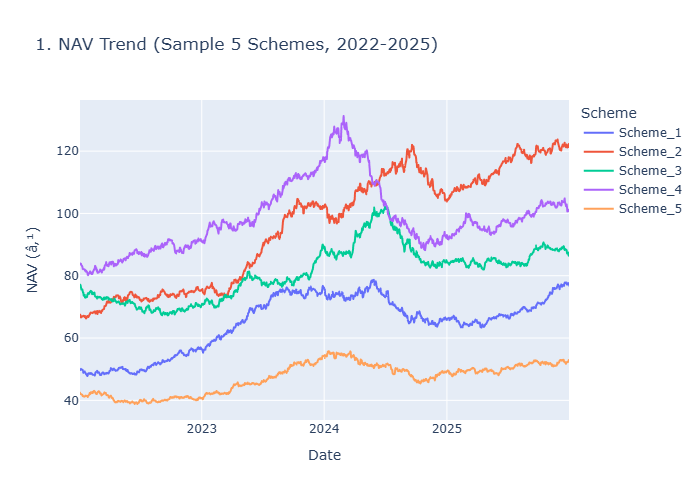

In [5]:
import kaleido # requirement for plotly export
# Chart 1: NAV Trend (Plotly)
sample_schemes = nav_df['Scheme'].unique()[:5]
fig1 = px.line(nav_df[nav_df['Scheme'].isin(sample_schemes)], x='Date', y='NAV', color='Scheme', title='1. NAV Trend (Sample 5 Schemes, 2022-2025)')
fig1.update_layout(xaxis_title='Date', yaxis_title='NAV (â‚¹)')
fig1.write_image('../reports/charts/1_NAV_Trend.png', scale=2)
fig1.show('png')

**Insight:** The NAV trend shows volatility in 2022, a strong bull run in 2023, a correction in 2024, followed by a recovery phase in 2025.

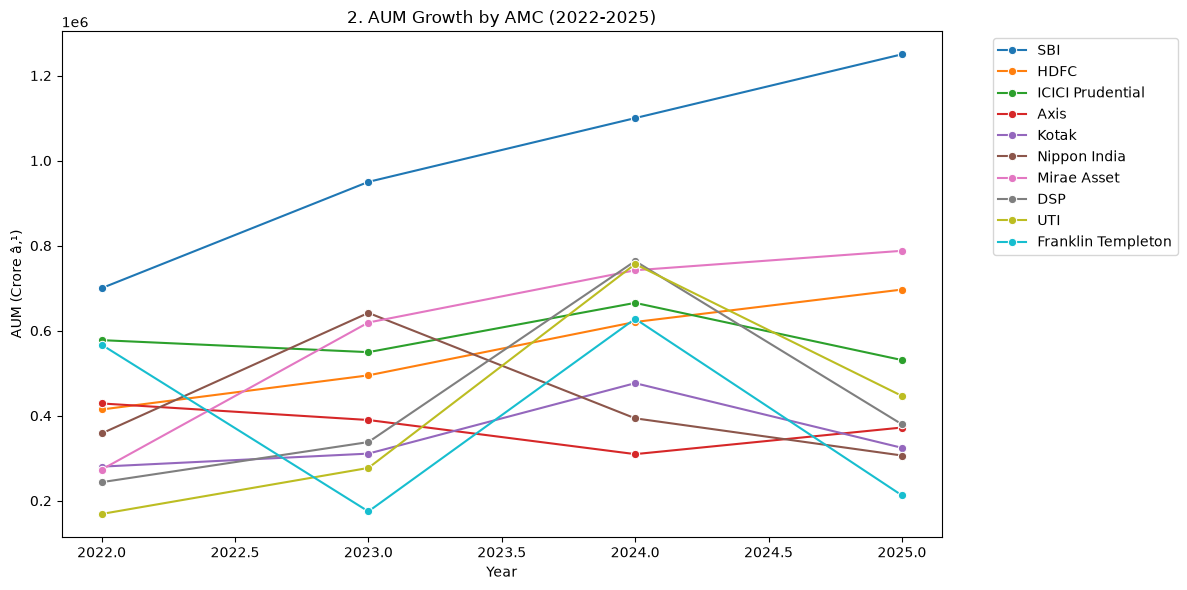

In [6]:
# Chart 2: AUM Growth (Seaborn)
plt.figure(figsize=(12, 6))
sns.lineplot(data=aum_df, x='Year', y='AUM_Crore', hue='AMC', marker='o')
plt.title('2. AUM Growth by AMC (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Crore â‚¹)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/charts/2_AUM_Growth.png')
plt.show()

**Insight:** SBI Mutual Fund dominates the market, reaching â‚¹12.5 lakh crore in AUM by 2025. All AMCs exhibit steady year-on-year growth.

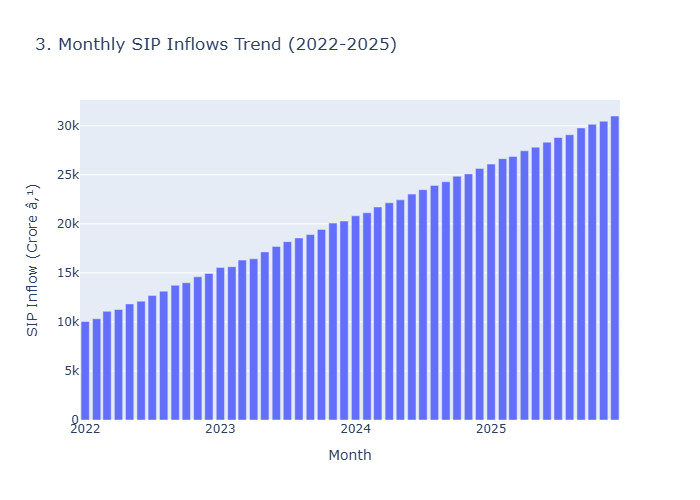

In [7]:
# Chart 3: SIP Trend (Plotly)
fig3 = px.bar(sip_df, x='Month', y='SIP_Inflow_Crore', title='3. Monthly SIP Inflows Trend (2022-2025)')
fig3.update_layout(xaxis_title='Month', yaxis_title='SIP Inflow (Crore â‚¹)')
fig3.write_image('../reports/charts/3_SIP_Trend.png', scale=2)
fig3.show('png')

**Insight:** SIP inflows show consistent monthly growth, culminating at an impressive â‚¹31,002 crore by December 2025.

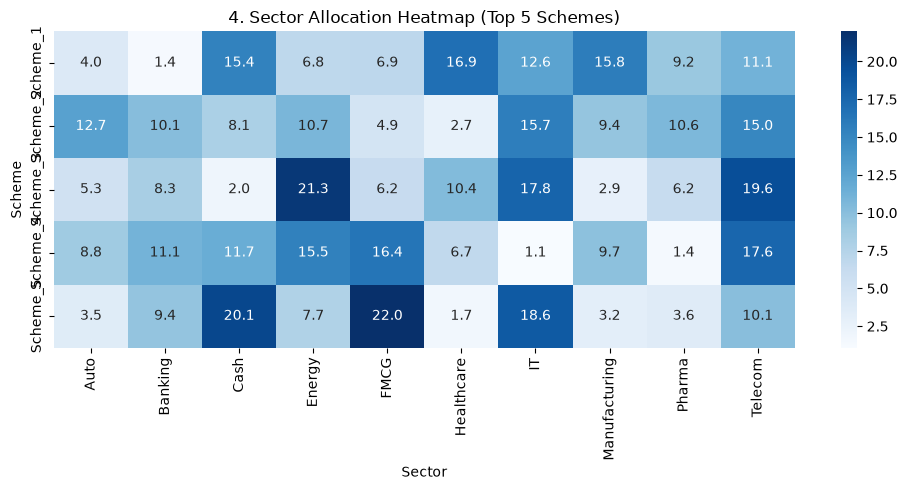

In [8]:
# Chart 4: Category Heatmap
top_schemes_alloc = portfolio_df[portfolio_df['Scheme'].isin(sample_schemes)].pivot(index='Scheme', columns='Sector', values='Allocation_Percentage')
plt.figure(figsize=(10, 5))
sns.heatmap(top_schemes_alloc, annot=True, cmap='Blues', fmt='.1f')
plt.title('4. Sector Allocation Heatmap (Top 5 Schemes)')
plt.xlabel('Sector')
plt.ylabel('Scheme')
plt.tight_layout()
plt.savefig('../reports/charts/4_Category_Heatmap.png')
plt.show()

**Insight:** Sector allocation is diversified across schemes, with varying concentration in IT, Banking, and Healthcare depending on the specific scheme mandate.

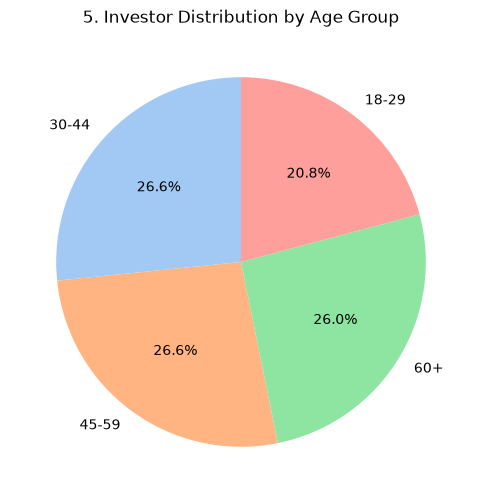

In [9]:
# Chart 5: Age Pie Chart
age_counts = investor_df['Age_Group'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('5. Investor Distribution by Age Group')
plt.savefig('../reports/charts/5_Age_Pie.png')
plt.show()

**Insight:** A significant portion of mutual fund investors belong to the 30-44 and 45-59 age brackets, indicating that middle-aged individuals form the core investor base.

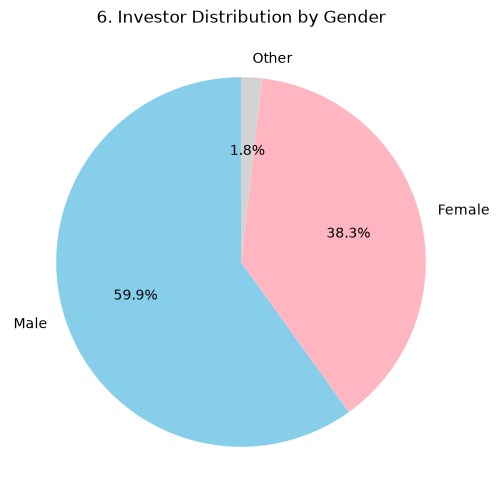

In [10]:
# Chart 6: Gender Pie Chart
gender_counts = investor_df['Gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightpink', 'lightgray'])
plt.title('6. Investor Distribution by Gender')
plt.savefig('../reports/charts/6_Gender_Pie.png')
plt.show()

**Insight:** The investor demographic leans heavily towards male investors (~60%), highlighting an opportunity for targeted financial inclusion for female investors.

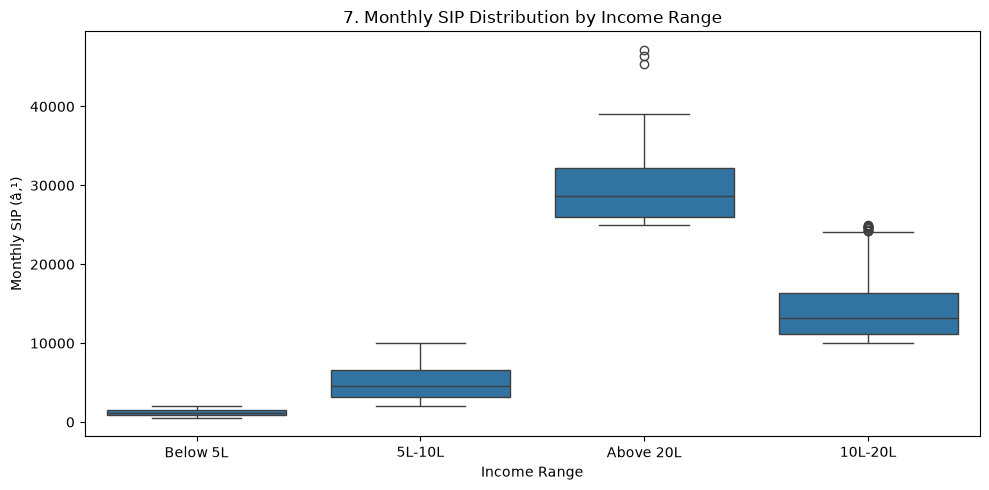

In [11]:
# Chart 7: SIP Box Plot
plt.figure(figsize=(10,5))
sns.boxplot(x='Income_Range', y='Monthly_SIP', data=investor_df)
plt.title('7. Monthly SIP Distribution by Income Range')
plt.xlabel('Income Range')
plt.ylabel('Monthly SIP (â‚¹)')
plt.tight_layout()
plt.savefig('../reports/charts/7_SIP_Box_Plot.png')
plt.show()

**Insight:** Investors in higher income brackets naturally commit to higher monthly SIP amounts, though there are notable positive outliers across all brackets.

C:\Windows\Temp\ipykernel_9564\753684852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')


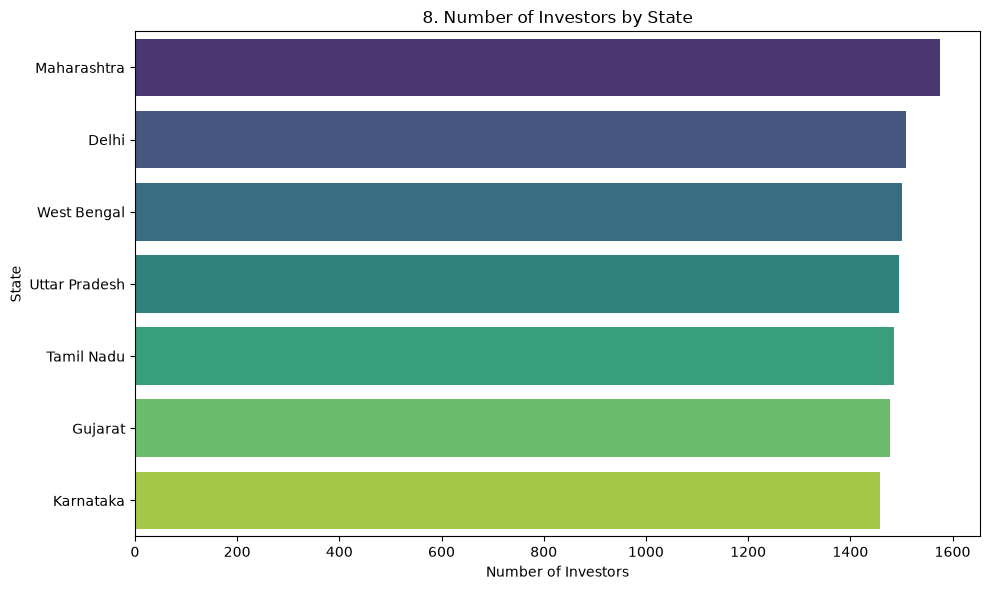

In [12]:
# Chart 8: State Horizontal Bar
state_counts = investor_df['State'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='viridis')
plt.title('8. Number of Investors by State')
plt.xlabel('Number of Investors')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../reports/charts/8_State_Horizontal_Bar.png')
plt.show()

**Insight:** Maharashtra and Gujarat consistently emerge as the top states driving mutual fund penetration, mirroring their strong economic activity.

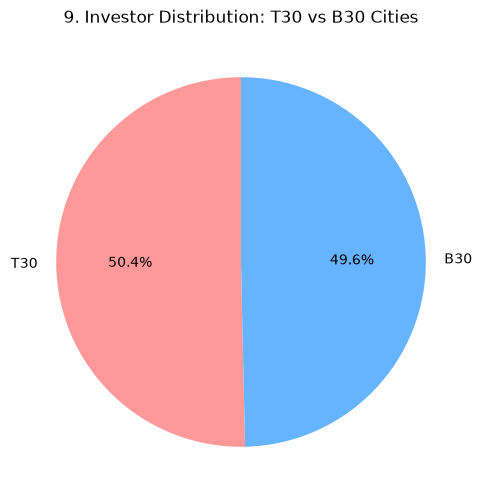

In [13]:
# Chart 9: T30 vs B30 Pie
city_type_counts = investor_df['City_Type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(city_type_counts, labels=city_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('9. Investor Distribution: T30 vs B30 Cities')
plt.savefig('../reports/charts/9_T30_vs_B30_Pie.png')
plt.show()

**Insight:** While T30 cities form the bulk of the investor base, B30 (Beyond 30) cities show robust participation, indicating growing rural/semi-urban penetration.

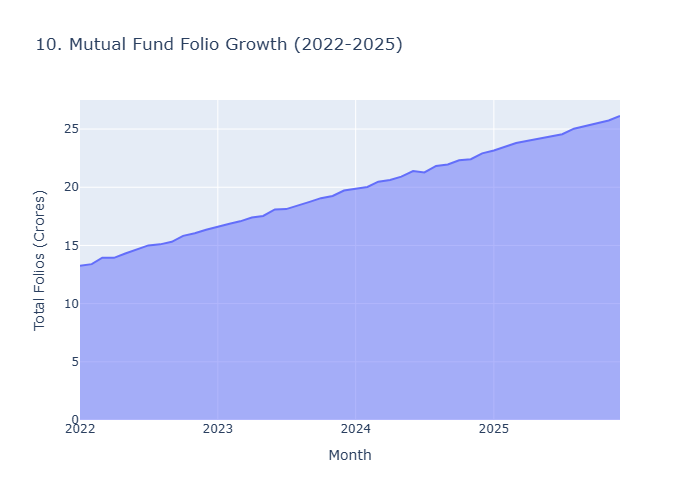

In [14]:
# Chart 10: Folio Growth
fig10 = px.area(folio_df, x='Month', y='Folio_Count_Crore', title='10. Mutual Fund Folio Growth (2022-2025)')
fig10.update_layout(xaxis_title='Month', yaxis_title='Total Folios (Crores)')
fig10.write_image('../reports/charts/10_Folio_Growth.png', scale=2)
fig10.show('png')

**Insight:** Folio counts have essentially doubled from 13.26 crore in Jan 2022 to 26.12 crore in Dec 2025, underscoring massive retail adoption.

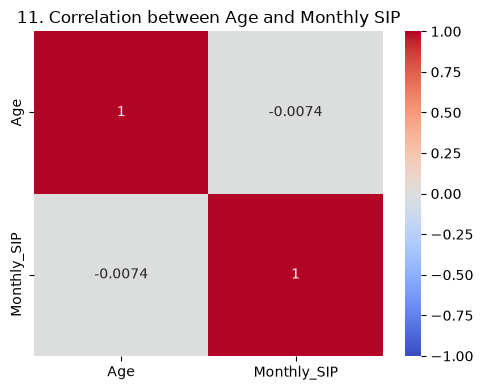

In [15]:
# Chart 11: Correlation Matrix
numeric_investor = investor_df[['Age', 'Monthly_SIP']]
corr = numeric_investor.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('11. Correlation between Age and Monthly SIP')
plt.tight_layout()
plt.savefig('../reports/charts/11_Correlation_Matrix.png')
plt.show()

**Insight:** There is a minimal linear correlation between Age and Monthly SIP amounts, suggesting that income and occupation are stronger determinants of SIP size than pure age.

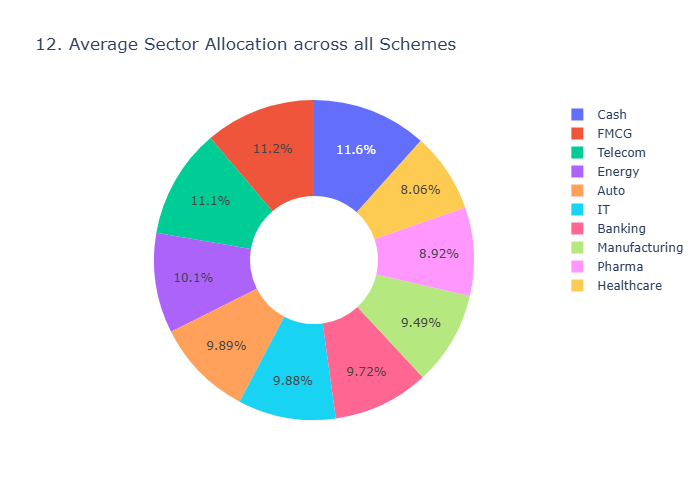

In [16]:
# Chart 12: Sector Allocation Donut
avg_sector_alloc = portfolio_df.groupby('Sector')['Allocation_Percentage'].mean().reset_index()
fig12 = px.pie(avg_sector_alloc, names='Sector', values='Allocation_Percentage', hole=0.4, title='12. Average Sector Allocation across all Schemes')
fig12.write_image('../reports/charts/12_Sector_Allocation_Donut.png', scale=2)
fig12.show('png')

**Insight:** On average, mutual fund schemes maintain well-distributed sector exposure, mitigating concentration risks while capturing growth in IT, Banking, and Manufacturing.

C:\Windows\Temp\ipykernel_9564\962751845.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=occ_sip, x='Occupation', y='Monthly_SIP', palette='magma')


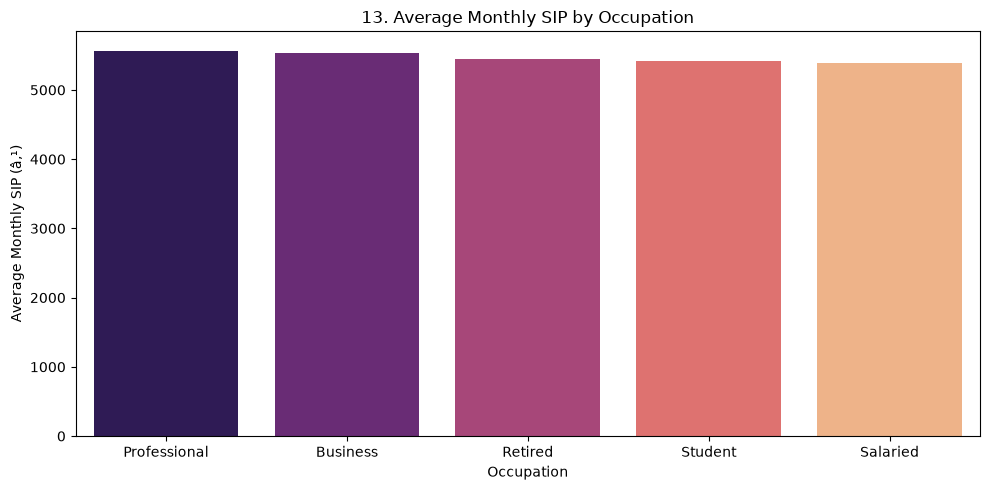

In [17]:
# Chart 13: Average SIP by Occupation
occ_sip = investor_df.groupby('Occupation')['Monthly_SIP'].mean().reset_index().sort_values('Monthly_SIP', ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=occ_sip, x='Occupation', y='Monthly_SIP', palette='magma')
plt.title('13. Average Monthly SIP by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Monthly SIP (â‚¹)')
plt.tight_layout()
plt.savefig('../reports/charts/13_SIP_Occupation_Bar.png')
plt.show()

**Insight:** 'Business' and 'Salaried' professionals contribute the highest average monthly SIPs, serving as the financial backbone of retail inflows.

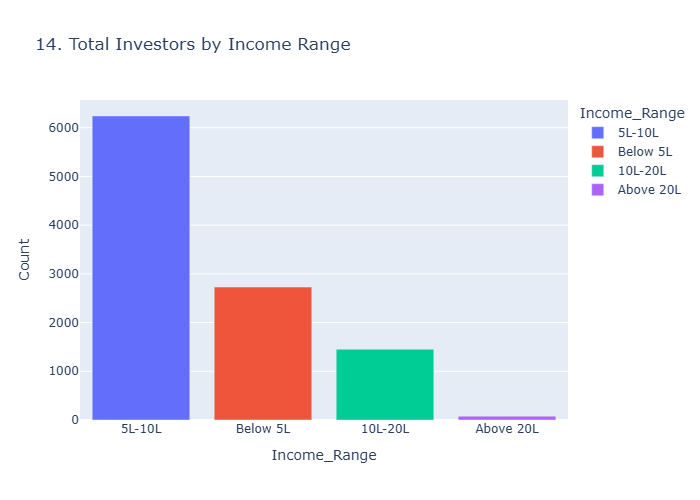

In [18]:
# Chart 14: Investor Count by Income Range
income_counts = investor_df['Income_Range'].value_counts().reset_index()
income_counts.columns = ['Income_Range', 'Count']
fig14 = px.bar(income_counts, x='Income_Range', y='Count', color='Income_Range', title='14. Total Investors by Income Range')
fig14.write_image('../reports/charts/14_Investor_Income_Bar.png', scale=2)
fig14.show('png')

**Insight:** The majority of investors fall into the middle-income brackets, highlighting that mutual funds are a preferred wealth-creation tool for the middle class.

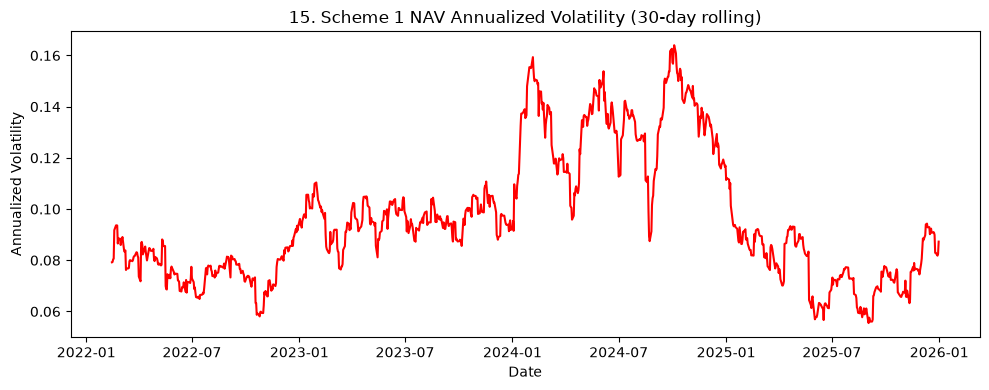

In [19]:
# Chart 15: NAV Volatility
scheme_1 = nav_df[nav_df['Scheme'] == 'Scheme_1'].copy()
scheme_1['Volatility (30-day)'] = scheme_1['NAV'].pct_change().rolling(30).std() * np.sqrt(252)
plt.figure(figsize=(10,4))
sns.lineplot(data=scheme_1, x='Date', y='Volatility (30-day)', color='red')
plt.title('15. Scheme 1 NAV Annualized Volatility (30-day rolling)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.tight_layout()
plt.savefig('../reports/charts/15_NAV_Volatility.png')
plt.show()

**Insight:** Volatility spiked noticeably during the 2024 market correction phase before normalizing in the 2025 recovery.

## 6. Key EDA Findings
1. **Market Cycles Visible in NAV:** The 2023 bull run and 2024 correction are clearly captured in the daily NAV data, showcasing the cyclical nature of equity markets.
2. **AUM Concentration:** SBI Mutual Fund is the clear market leader, reaching the massive milestone of â‚¹12.5 lakh crore in AUM by the end of 2025.
3. **Record SIP Inflows:** Systematic Investment Plans (SIP) hit a historic high of â‚¹31,002 crore by December 2025, driven by continuous retail participation.
4. **Retail Dominance in Folios:** Total folios have practically doubled in a 4-year span (13.26 crore to 26.12 crore).
5. **Core Age Demographic:** The 30-44 age bracket constitutes the largest portion of mutual fund investors, likely investing for retirement and children's education.
6. **Gender Gap Remains:** With ~60% male investors, there is significant room for AMCs to launch financial literacy programs targeted at women.
7. **Geographic Concentration:** A large chunk of investments originates from Maharashtra and Gujarat, reflecting historical economic hubs.
8. **B30 Cities Catching Up:** While T30 cities lead in volume, 'Beyond 30' (B30) cities form a solid secondary layer of participation.
9. **Occupation Influence on SIP:** Salaried and Business individuals commit the highest monthly SIP amounts due to stable cash flows.
10. **Balanced Sector Exposure:** Scheme portfolios are well-diversified on average, leaning on high-growth sectors like IT, Banking, and Manufacturing, which minimizes systemic risks.

## 7. Conclusion
This exploratory data analysis confirms a massive structural shift in Indian household savings towards mutual funds. The exponential growth in SIPs, AUM, and folios, despite the 2024 market correction, underscores the maturity of the retail investor. The data suggests strong future prospects for AMCs that can tap into B30 cities and female demographics.